In [3]:
# @title Importing

from __future__ import annotations

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.utils.tensorboard import SummaryWriter
from torch.profiler import schedule
import torchmetrics
from ignite.engine import Events
from ignite.metrics import Metric, Loss
from ignite.handlers import global_step_from_engine, EarlyStopping
from torch.optim.lr_scheduler import _LRScheduler, ReduceLROnPlateau, CosineAnnealingWarmRestarts, ChainedScheduler
from ignite.contrib.handlers import TensorboardLogger
from ignite.contrib.handlers.tensorboard_logger import *
from ignite.exceptions import NotComputableError

import lightning as L
import pytorch_lightning as pl
from pytorch_lightning.loggers import TensorBoardLogger
from lightning.pytorch.callbacks import ModelCheckpoint, ModelSummary
from lightning.pytorch.callbacks.early_stopping import EarlyStopping
from lightning.pytorch.profilers import SimpleProfiler, PyTorchProfiler
from lightning.pytorch.utilities.warnings import PossibleUserWarning

from torch.optim.lr_scheduler import SequentialLR

from captum.attr import Saliency, IntegratedGradients, Occlusion, GradientShap, ShapleyValueSampling, ShapleyValues, FeatureAblation, FeaturePermutation

import shap

from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA, FastICA

import statsmodels.api as sm
from statsmodels.multivariate.factor_rotation import promax
from statsmodels.stats.multitest import multipletests

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.cm import ScalarMappable
from matplotlib import colors
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch
import colormaps as cmaps
import plotly.graph_objects as go

from tqdm.auto import tqdm

import seaborn as sns

from scipy import stats
from scipy.stats import norm, ttest_rel, ttest_1samp, wilcoxon, ttest_ind
import scipy.io as sio
from scipy.interpolate import griddata

from joblib import Parallel, delayed

import numpy as np
import pandas as pd
import datetime
import time
import os
import random
import sys
import glob
import ipynbname
import pickle
import json
import math
import warnings
import copy
import logging
from pathlib import Path

logging.getLogger("lightning.pytorch").setLevel(logging.ERROR)
logging.getLogger("pytorch_lightning").setLevel(logging.ERROR)

warnings.filterwarnings("ignore", category=PossibleUserWarning)
warnings.filterwarnings("ignore", message=".*does not have many workers.*")
warnings.filterwarnings("ignore", message=r".*Checkpoint directory .* exists and is not empty.*", category=UserWarning, module=r"lightning\.pytorch\.callbacks\.model_checkpoint")

SEED = 1

def seed_everything(seed):
    os.environ["PYTHONHASHSEED"] = str(seed)

    if torch.cuda.is_available():
        os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

    torch.backends.cuda.matmul.allow_tf32 = False
    torch.backends.cudnn.allow_tf32 = False

    torch.set_float32_matmul_precision("highest")
    torch.use_deterministic_algorithms(True, warn_only=False)


seed_everything(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

c:\Users\A\miniconda3\lib\site-packages\torch\utils\_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(
C:\Users\A\AppData\Local\Temp\ipykernel_19072\1352675481.py:17: DeprecationWarning: c:\Users\A\miniconda3\lib\site-packages\ignite\contrib\handlers\tensorboard_logger.py has been moved to /ignite/handlers/tensorboard_logger.py and will be removed in version 0.6.0.
 Please refer to the documentation for more details.
  from ignite.contrib.handlers.tensorboard_logger import *


In [4]:
# @title Configuration

class DotDict(dict):
    def __init__(self, d=None):
        super().__init__()
        if d:
            for k, v in d.items():
                self[k] = self._wrap(v)

    def _wrap(self, value):
        if isinstance(value, dict):
            return DotDict(value)
        if isinstance(value, list):
            return [self._wrap(v) for v in value]
        return value

    def __getattr__(self, name):
        try:
            return self[name]
        except KeyError:
            raise AttributeError(name)

    def __setattr__(self, name, value):
        self[name] = self._wrap(value)

    def __delattr__(self, name):
        try:
            del self[name]
        except KeyError:
            raise AttributeError(name)

    def to_dict(self):
        out = {}
        for k, v in self.items():
            if isinstance(v, DotDict):
                out[k] = v.to_dict()
            elif isinstance(v, list):
                out[k] = [x.to_dict() if isinstance(x, DotDict) else x for x in v]
            else:
                out[k] = v
        return out

    def __deepcopy__(self, memo):
        return DotDict(copy.deepcopy(self.to_dict(), memo))


Conf = DotDict({
    "run_id": 1,
    "seed": SEED,
    "paths": {
        "data": "data.mat",
        "logs": "/lightning_logs",
    },
    "session_idx": 15,
    "device": device,
})

In [13]:
# @title Plots

def save_figure(fig, file_name, file_path, ext=".png", **savefig_kwargs):
    file_path = Path(file_path)
    file_path.mkdir(parents=True, exist_ok=True)

    fig.savefig(file_path / f"{file_name}{ext}", dpi=100, bbox_inches="tight", pad_inches=0.25, **savefig_kwargs)

    plt.close(fig)

    return file_path


def plot_unit_spikes(
    spikes,
    unit_idx,
    title,
    file_name,
    file_path,
    bin_times=None,
    trial_names=None,
    cmap="viridis",
    figsize=(10, 7),
    show=False,
):
    to_numpy = lambda x: (
        x.detach().cpu().numpy()
        if torch.is_tensor(x)
        else np.asarray(x)
    )

    spikes = to_numpy(spikes)
    unit_spikes = spikes[:, unit_idx, :]

    if unit_spikes.ndim != 2:
        raise ValueError(
            "spikes must have shape (n_trials, n_units, n_bins). "
            f"Received shape {spikes.shape}."
        )

    n_trials, n_bins = unit_spikes.shape

    if bin_times is None:
        bin_times = np.arange(n_bins)
    if trial_names is None:
        trial_names = np.arange(n_trials)

    bin_times = np.asarray(bin_times)
    trial_names = np.asarray(trial_names)

    if bin_times.size != n_bins:
        raise ValueError("bin_times must contain one value per bin.")
    if trial_names.size != n_trials:
        raise ValueError("trial_names must contain one name per trial.")

    mean_by_bin = np.nanmean(unit_spikes, axis=0)
    mean_by_trial = np.nanmean(unit_spikes, axis=1)

    fig = plt.figure(figsize=figsize, layout="constrained")
    gs = fig.add_gridspec(
        2,
        2,
        width_ratios=[0.25, 1],
        height_ratios=[1, 0.25],
        wspace=0.03,
        hspace=0.03,
    )

    ax_main = fig.add_subplot(gs[0, 1])
    ax_left = fig.add_subplot(gs[0, 0], sharey=ax_main)
    ax_bottom = fig.add_subplot(gs[1, 1])
    ax_corner = fig.add_subplot(gs[1, 0])
    ax_corner.axis("off")

    im = ax_main.imshow(
        unit_spikes,
        origin="lower",
        aspect="auto",
        interpolation="nearest",
        cmap=cmap,
    )

    trial_tick_idx = np.linspace(
        0,
        n_trials - 1,
        min(10, n_trials),
        dtype=int,
    )

    ax_main.set(
        ylabel="Trial",
        xticks=[],
        yticks=trial_tick_idx,
        yticklabels=trial_names[trial_tick_idx],
    )
    ax_main.tick_params(axis="y", labelsize=7)
    ax_main.spines[["top", "right"]].set_visible(False)

    trial_idx = np.arange(n_trials)

    ax_left.plot(
        mean_by_trial,
        trial_idx,
        color="C0",
        linewidth=0.5,
    )

    ax_left.fill_betweenx(
        trial_idx,
        0,
        mean_by_trial,
        color="C0",
        alpha=0.20,
    )

    left_limit = max(np.nanmax(mean_by_trial), np.finfo(float).eps)

    ax_left.set(
        xlim=(0, 1.1 * left_limit),
        xlabel="Mean\nspike",
    )
    ax_left.tick_params(axis="x", labelsize=7)
    ax_left.tick_params(axis="y", left=False, labelleft=False)
    ax_left.spines[["top", "right", "left"]].set_visible(False)

    ax_bottom.plot(
        bin_times,
        mean_by_bin,
        color="C0",
        linewidth=1.5,
    )

    ax_bottom.fill_between(
        bin_times,
        0,
        mean_by_bin,
        color="C0",
        alpha=0.20,
    )

    ax_bottom.set(
        xlabel="Time",
        ylabel="Mean\nspike",
    )
    ax_bottom.tick_params(axis="both", labelsize=7)
    ax_bottom.spines[["top", "right"]].set_visible(False)

    cbar = fig.colorbar(
        im,
        ax=ax_main,
        fraction=0.025,
        pad=0.02,
    )
    cbar.set_label("Spike activity", fontsize=8)
    cbar.ax.tick_params(labelsize=7)

    fig.suptitle(title, fontweight="bold")

    if show:
        plt.show()

    return save_figure(fig, file_name, file_path)


def plot_spike_summary(
    spikes,
    title,
    file_name,
    file_path,
    metric="mean",
    k=4.0,
    unit_threshold=None,
    trial_threshold=None,
    unit_names=None,
    trial_names=None,
    cmap="viridis",
    figsize=(10, 7),
    show=True,
):
    to_numpy = lambda x: (
        x.detach().cpu().numpy()
        if torch.is_tensor(x)
        else np.asarray(x)
    )

    metric_functions = {
        "mean": np.nanmean,
        "median": np.nanmedian,
        "max": np.nanmax,
        "min": np.nanmin,
        "std": np.nanstd,
        "var": np.nanvar,
        "sum": np.nansum,
    }

    if metric not in [*metric_functions.keys(), "outlier_rate"]:
        raise ValueError(
            "metric must be one of: "
            f"{[*metric_functions.keys(), 'outlier_rate']}."
        )

    def parse_threshold(threshold):
        if threshold is None:
            return None, None

        if np.isscalar(threshold):
            return None, float(threshold)

        threshold = tuple(threshold)

        if len(threshold) != 2:
            raise ValueError(
                "threshold must be None, a scalar, or (low, high)."
            )

        low, high = threshold

        low = None if low is None else float(low)
        high = None if high is None else float(high)

        return low, high

    spikes = to_numpy(spikes).astype(float)

    if spikes.ndim != 3:
        raise ValueError(
            "spikes must have shape (n_trials, n_units, n_bins). "
            f"Received shape {spikes.shape}."
        )

    if k <= 0:
        raise ValueError("k must be greater than zero.")

    n_trials, n_units, n_bins = spikes.shape

    if unit_names is None:
        unit_names = np.arange(n_units)

    if trial_names is None:
        trial_names = np.arange(n_trials)

    unit_names = np.asarray(unit_names)
    trial_names = np.asarray(trial_names)

    if unit_names.size != n_units:
        raise ValueError("unit_names must contain one name per unit.")

    if trial_names.size != n_trials:
        raise ValueError("trial_names must contain one name per trial.")

    if metric == "outlier_rate":
        median = np.nanmedian(spikes, axis=0, keepdims=True)
        mad = np.nanmedian(
            np.abs(spikes - median),
            axis=0,
            keepdims=True,
        )

        robust_scale = np.maximum(
            1.4826 * mad,
            1.0,
        )

        flagged = spikes > median + k * robust_scale

        summary = np.nanmean(flagged, axis=2)
        unit_score = np.nanmean(flagged, axis=(0, 2))
        trial_score = np.nanmean(flagged, axis=(1, 2))

        metric_name = f"Outlier rate (k={k:g})"
        colorbar_label = "Proportion of flagged bins"
    else:
        metric_function = metric_functions[metric]

        summary = metric_function(spikes, axis=2)
        unit_score = metric_function(spikes, axis=(0, 2))
        trial_score = metric_function(spikes, axis=(1, 2))

        metric_name = metric.title()
        colorbar_label = f"{metric.title()} spike value"

    unit_low, unit_high = parse_threshold(unit_threshold)
    trial_low, trial_high = parse_threshold(trial_threshold)

    bad_units = np.zeros(n_units, dtype=bool)
    bad_trials = np.zeros(n_trials, dtype=bool)

    if unit_low is not None:
        bad_units |= unit_score < unit_low

    if unit_high is not None:
        bad_units |= unit_score > unit_high

    if trial_low is not None:
        bad_trials |= trial_score < trial_low

    if trial_high is not None:
        bad_trials |= trial_score > trial_high

    units_to_remove = np.where(bad_units)[0]
    trials_to_remove = np.where(bad_trials)[0]

    unit_tick_idx = np.linspace(
        0,
        n_units - 1,
        min(10, n_units),
        dtype=int,
    )

    trial_tick_idx = np.linspace(
        0,
        n_trials - 1,
        min(10, n_trials),
        dtype=int,
    )

    fig = plt.figure(figsize=figsize, layout="constrained")
    gs = fig.add_gridspec(
        2,
        2,
        width_ratios=[0.25, 1],
        height_ratios=[1, 0.25],
        wspace=0.03,
        hspace=0.03,
    )

    ax_main = fig.add_subplot(gs[0, 1])
    ax_left = fig.add_subplot(gs[0, 0], sharey=ax_main)
    ax_bottom = fig.add_subplot(gs[1, 1], sharex=ax_main)
    ax_corner = fig.add_subplot(gs[1, 0])
    ax_corner.axis("off")

    im = ax_main.imshow(
        summary.T,
        origin="lower",
        aspect="auto",
        interpolation="nearest",
        cmap=cmap,
    )

    ax_main.set(
        xlabel="Trial",
        ylabel="Unit",
        xticks=trial_tick_idx,
        xticklabels=trial_names[trial_tick_idx],
        yticks=unit_tick_idx,
        yticklabels=unit_names[unit_tick_idx],
    )
    ax_main.tick_params(axis="x", labelrotation=90, labelsize=7)
    ax_main.tick_params(axis="y", labelsize=7)
    ax_main.spines[["top", "right"]].set_visible(False)

    unit_idx = np.arange(n_units)
    trial_idx = np.arange(n_trials)

    ax_left.scatter(
        unit_score,
        unit_idx,
        color="C0",
        s=8,
        alpha=0.7,
    )

    if unit_low is not None:
        ax_left.axvline(
            unit_low,
            color="tab:red",
            linewidth=1,
        )

    if unit_high is not None:
        ax_left.axvline(
            unit_high,
            color="tab:red",
            linewidth=1,
        )

    ax_left.scatter(
        unit_score[bad_units],
        unit_idx[bad_units],
        color="tab:red",
        s=18,
        zorder=3,
    )

    ax_left.set_xlabel(metric_name)
    ax_left.tick_params(axis="x", labelsize=7)
    ax_left.tick_params(axis="y", left=False, labelleft=False)
    ax_left.spines[["top", "right", "left"]].set_visible(False)

    ax_bottom.scatter(
        trial_idx,
        trial_score,
        color="C0",
        s=8,
        alpha=0.7,
    )

    if trial_low is not None:
        ax_bottom.axhline(
            trial_low,
            color="tab:red",
            linewidth=1,
        )

    if trial_high is not None:
        ax_bottom.axhline(
            trial_high,
            color="tab:red",
            linewidth=1,
        )

    ax_bottom.scatter(
        trial_idx[bad_trials],
        trial_score[bad_trials],
        color="tab:red",
        s=18,
        zorder=3,
    )

    ax_bottom.set(
        xlabel="Trial",
        ylabel=metric_name,
        xticks=trial_tick_idx,
        xticklabels=trial_names[trial_tick_idx],
    )
    ax_bottom.tick_params(axis="x", labelrotation=90, labelsize=7)
    ax_bottom.tick_params(axis="y", labelsize=7)
    ax_bottom.spines[["top", "right"]].set_visible(False)

    for unit_idx in units_to_remove:
        ax_main.axhline(
            unit_idx - 0.5,
            color="tab:red",
            linewidth=0.6,
        )
        ax_main.axhline(
            unit_idx + 0.5,
            color="tab:red",
            linewidth=0.6,
        )

    for trial_idx in trials_to_remove:
        ax_main.axvline(
            trial_idx - 0.5,
            color="tab:red",
            linewidth=0.6,
        )
        ax_main.axvline(
            trial_idx + 0.5,
            color="tab:red",
            linewidth=0.6,
        )

    cbar = fig.colorbar(
        im,
        ax=ax_main,
        fraction=0.025,
        pad=0.02,
    )
    cbar.set_label(colorbar_label, fontsize=8)
    cbar.ax.tick_params(labelsize=7)

    fig.suptitle(
        f"{title}: {metric_name}",
        fontweight="bold",
    )

    if show:
        plt.show()

    save_figure(fig, file_name, file_path)

    return trials_to_remove, units_to_remove


In [6]:
data = sio.loadmat(
    Conf.paths.data,
    squeeze_me=True,
    struct_as_record=False
)

for session_idx, session_name in enumerate(data["session_names"]):
    session_spikes = np.transpose(
        data["spikes"][session_idx],
        (1, 0, 2)
    )

    n_trials = session_spikes.shape[0]
    n_units = session_spikes.shape[1]

    print(
        f"{session_idx}: {session_name} | "
        f"{n_trials} trials | "
        f"{n_units} units"
    )

0: 63 | 155 trials | 57 units
1: 64 | 174 trials | 49 units
2: 67 | 223 trials | 45 units
3: 68 | 236 trials | 55 units
4: 69 | 531 trials | 56 units
5: 71 | 441 trials | 71 units
6: 74 | 437 trials | 47 units
7: 76 | 522 trials | 37 units
8: 79 | 577 trials | 36 units
9: 80 | 579 trials | 43 units
10: 84 | 670 trials | 43 units
11: 95 | 275 trials | 55 units
12: 97 | 323 trials | 40 units
13: 98 | 317 trials | 64 units
14: 99 | 432 trials | 64 units
15: 109 | 783 trials | 80 units
16: 110 | 595 trials | 62 units
17: 111 | 878 trials | 60 units
18: 112 | 916 trials | 63 units


In [7]:
session_name = data['session_names'][Conf.session_idx]
spikes = data['spikes'][Conf.session_idx]
position_vars = data['position_vars'][Conf.session_idx]
position_var_names = data['position_var_names']
task_vars = data['task_vars'][Conf.session_idx]
task_var_names = data['task_var_names']
events = data['events'][Conf.session_idx]
event_names = data['event_names']
unit_names = data['unit_names'][Conf.session_idx]
channel_names = data['channel_names'][Conf.session_idx]
unit_types = data['unit_types'][Conf.session_idx]
bin_size = data['bin_size']
bin_times = data['bin_times']
variable_names = np.concatenate((position_var_names, task_var_names), axis=0)

spikes  = np.transpose(spikes, (1, 0, 2)) * 0.2
position_vars  = np.transpose(position_vars, (1, 0, 2))
task_vars = np.transpose(task_vars, (1, 0))

dense = [0, 1, 2, 3]
sparse = [4, 5, 6]

In [8]:
spike_mask_finite = np.isfinite(spikes).all(axis=(1, 2))
position_vars_mask_finite = np.isfinite(position_vars).all(axis=(1, 2))
task_vars_mask_finite = np.isfinite(task_vars).all(axis=1)
mask_finite = spike_mask_finite & position_vars_mask_finite & task_vars_mask_finite
print("deleted infinite spike:", (~spike_mask_finite).sum())
print("deleted infinite position_vars:", (~position_vars_mask_finite).sum())
print("deleted infinite task_vars:", (~task_vars_mask_finite).sum())

position_vars_mask_zero = (position_vars == 0).all(axis=(1, 2))
print("deleted zero position_vars:", (position_vars_mask_zero).sum())

task_vars_mask_over = np.zeros(task_vars.shape[0], dtype=bool)
for task_var_name in ['tunp', 'tslp']:
    task_var_idx = np.where(task_var_names == task_var_name)[0][0]
    task_var_mask_over = task_vars[:, task_var_idx] > 100
    print(f"deleted over {task_var_name}:", task_var_mask_over.sum())
    task_vars_mask_over |= task_var_mask_over

trials_mask_keep = mask_finite & ~position_vars_mask_zero & ~task_vars_mask_over

spikes = spikes[trials_mask_keep]
position_vars = position_vars[trials_mask_keep]
task_vars = task_vars[trials_mask_keep]

for task_var_name in ['tunp', 'tslp']:
    task_var_idx = np.where(task_var_names == task_var_name)[0][0]
    task_vars[:, task_var_idx] = np.log(task_vars[:, task_var_idx])

scaler = MinMaxScaler(feature_range=(0, 1))
task_vars = scaler.fit_transform(task_vars)

n_trials, n_units , n_bins = spikes.shape
n_trials, n_position_vars, n_bins = position_vars.shape
n_trials, n_task_vars = task_vars.shape

Conf.data = DotDict()
Conf.data.bin_size = bin_size
Conf.data.n_bins = n_bins
Conf.data.n_position_vars = n_position_vars
Conf.data.n_dense_vars = len(dense)
Conf.data.n_sparse_vars = len(sparse)
Conf.data.n_vars = n_position_vars + len(dense) + len(sparse)
Conf.data.n_units = n_units

deleted infinite spike: 5
deleted infinite position_vars: 0
deleted infinite task_vars: 5
deleted zero position_vars: 0
deleted over tunp: 0
deleted over tslp: 0


In [9]:
for unit_idx, unit_name in enumerate(unit_names):
    plot_unit_spikes(
        spikes=spikes,
        unit_idx=unit_idx,
        title=f"Spike Activity | Unit {unit_name}",
        file_name=f"spike-activity-unit-{unit_idx}",
        file_path=f"./plot/sessions/session-{session_idx}/preprocessing/spikes",
        bin_times=bin_times,
        trial_names=np.arange(spikes.shape[0]),
    )

In [10]:
units_to_remove = [14, 15, 82]
units_mask_delete = np.isin(unit_names, units_to_remove)
unit_names = unit_names[~units_mask_delete]
spikes = spikes[:, ~units_mask_delete]

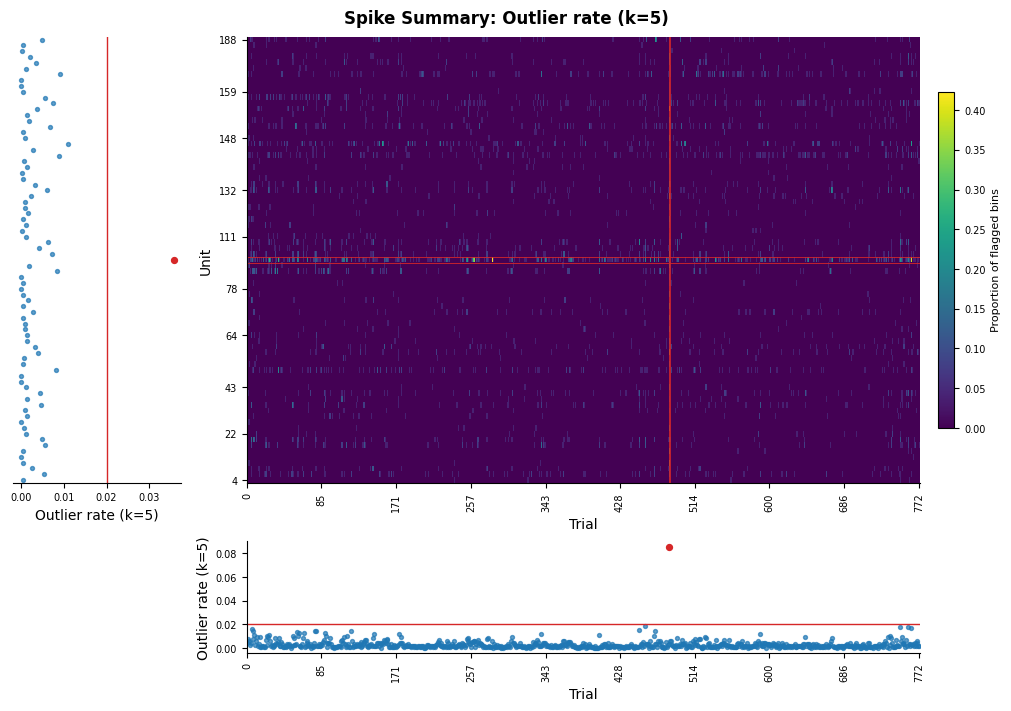

In [14]:
trials_to_remove, units_to_remove = plot_spike_summary(
    spikes=spikes,
    title="Spike Summary",
    file_name="spike-summary-outlier-rate-thresholded",
    file_path="./plot/spikes",
    metric="outlier_rate",
    k=5.0,
    unit_threshold=0.02,
    trial_threshold=0.02,
    unit_names=unit_names,
    trial_names=np.arange(spikes.shape[0]),
)